In [7]:
from google.colab import files

uploaded = files.upload()


Please choose your dataset zip file (the one your doctor gave you).


Saving archive.zip to archive.zip


In [8]:
import zipfile, os

zip_filename = "archive.zip"
zip_path = "/content/" + zip_filename

extract_dir = "/content/dental_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to:", extract_dir)
print("Inside that folder:", os.listdir(extract_dir))


Extracted to: /content/dental_dataset
Inside that folder: ['Cavity Dataset']


In [9]:
import os

dataset_root = "/content/dental_dataset/Cavity Dataset"

print("Dataset root:", dataset_root)
print("Contents:", os.listdir(dataset_root))


Dataset root: /content/dental_dataset/Cavity Dataset
Contents: ['train', 'data.yaml', 'README.dataset.txt', 'test', 'README.roboflow.txt', 'valid']


In [10]:
import os

train_root = os.path.join(dataset_root, "train")
print("Train folder contents:", os.listdir(train_root))

train_images_dir = os.path.join(train_root, "images")
train_labels_dir = os.path.join(train_root, "labelTxt")

print("Train images dir:", train_images_dir)
print("Train labels dir:", train_labels_dir)

print("Number of image files in train/images:",
      len(os.listdir(train_images_dir)))
print("Number of label files in train/labelTxt:",
      len(os.listdir(train_labels_dir)))


Train folder contents: ['labelTxt', 'images']
Train images dir: /content/dental_dataset/Cavity Dataset/train/images
Train labels dir: /content/dental_dataset/Cavity Dataset/train/labelTxt
Number of image files in train/images: 287
Number of label files in train/labelTxt: 287


In [18]:
import glob
import cv2
import numpy as np
import os

IMG_SIZE = 224  # same as before

def load_split(images_dir):
    X_list = []
    y_list = []

    image_paths = glob.glob(os.path.join(images_dir, "*.*"))
    print(f"{images_dir} → {len(image_paths)} images")

    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.GaussianBlur(img, (3, 3), 0)

        fname = os.path.basename(path).lower()

        if "unhealthy_teeth" in fname:
            label = 1
        elif "healthy_teeth" in fname:
            label = 0
        else:
            continue

        X_list.append(img)
        y_list.append(label)

    X = np.array(X_list, dtype=np.float32)[..., np.newaxis]
    y = np.array(y_list, dtype=np.int32)

    print(" shape:", X.shape, y.shape)
    unique, counts = np.unique(y, return_counts=True)
    print(" class counts:", dict(zip(unique, counts)))
    return X, y

# dirs for valid & test
val_images_dir  = os.path.join(dataset_root, "valid", "images")
test_images_dir = os.path.join(dataset_root, "test", "images")

X_val,  y_val  = load_split(val_images_dir)
X_test, y_test = load_split(test_images_dir)

# normalize
X_val  = X_val  / 255.0
X_test = X_test / 255.0


/content/dental_dataset/Cavity Dataset/valid/images → 93 images
 shape: (78, 224, 224, 1) (78,)
 class counts: {np.int32(0): np.int64(42), np.int32(1): np.int64(36)}
/content/dental_dataset/Cavity Dataset/test/images → 38 images
 shape: (38, 224, 224, 1) (38,)
 class counts: {np.int32(0): np.int64(37), np.int32(1): np.int64(1)}


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = (IMG_SIZE, IMG_SIZE, 1)  # (224, 224, 1)

def create_custom_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        # binary output: caries vs healthy
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

custom_model = create_custom_cnn(input_shape)
custom_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,937,985 (49.35 MB)

 Trainable params: 12,937,985 (49.35 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "custom_cnn_best.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history_custom = custom_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)


Class weights: {0: 1.9344262295081966, 1: 0.6742857142857143}
Epoch 1/25
 5/15 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5642 - loss: 0.6662

KeyboardInterrupt: 

In [21]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_val_prob = custom_model.predict(X_val)

y_val_pred = (y_val_prob >= 0.5).astype("int32").ravel()

print("Shapes:", y_val.shape, y_val_pred.shape)

acc  = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, zero_division=0)
rec  = recall_score(y_val, y_val_pred, zero_division=0)
f1   = f1_score(y_val, y_val_pred, zero_division=0)

print(f"Validation accuracy : {acc:.4f}")
print(f"Validation precision: {prec:.4f}")
print(f"Validation recall   : {rec:.4f}")
print(f"Validation F1-score : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_val, y_val_pred, target_names=["healthy", "caries"]))


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
Shapes: (78,) (78,)
Validation accuracy : 0.4615
Validation precision: 0.4615
Validation recall   : 1.0000
Validation F1-score : 0.6316

Classification report:
              precision    recall  f1-score   support

     healthy       0.00      0.00      0.00        42
      caries       0.46      1.00      0.63        36

    accuracy                           0.46        78
   macro avg       0.23      0.50      0.32        78
weighted avg       0.21      0.46      0.29        78



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


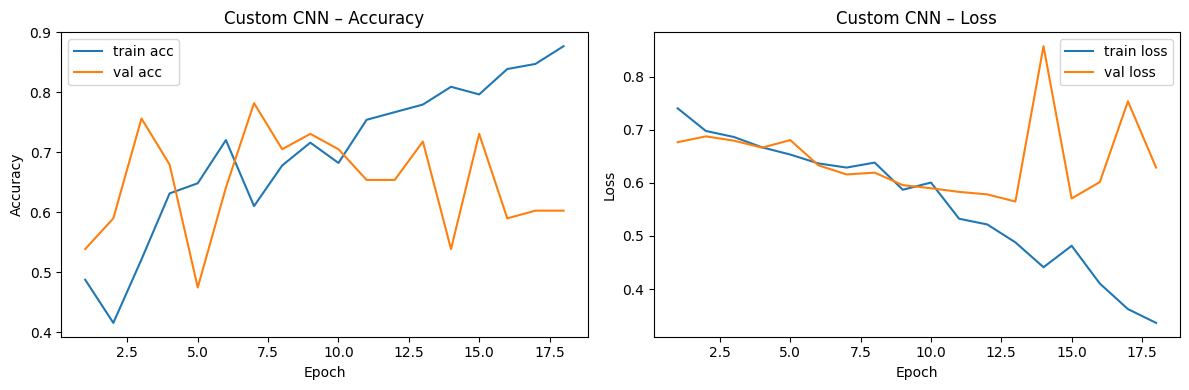

In [49]:
import matplotlib.pyplot as plt

history_dict = history_custom.history

epochs = range(1, len(history_dict['loss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], label='train acc')
plt.plot(epochs, history_dict['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Custom CNN – Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], label='train loss')
plt.plot(epochs, history_dict['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Custom CNN – Loss')
plt.legend()

plt.tight_layout()
plt.show()


Test loss: 0.6118
Test accuracy: 0.7105
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step

Detailed Test Metrics:
Accuracy : 0.7105
Precision: 0.0833
Recall   : 1.0000
F1-score : 0.1538

Classification report (test):
              precision    recall  f1-score   support

     healthy       1.00      0.70      0.83        37
      caries       0.08      1.00      0.15         1

    accuracy                           0.71        38
   macro avg       0.54      0.85      0.49        38
weighted avg       0.98      0.71      0.81        38



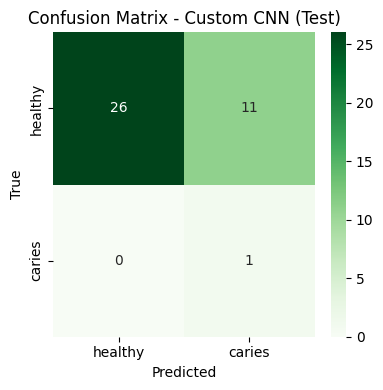

In [50]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_acc = custom_model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_test_prob = custom_model.predict(X_test)
y_test_pred = (y_test_prob >= 0.5).astype("int32").ravel()

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)

print("\nDetailed Test Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, target_names=["healthy", "caries"]))

cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["healthy", "caries"],
    yticklabels=["healthy", "caries"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Custom CNN (Test)")
plt.tight_layout()
plt.show()


In [51]:
import numpy as np

def to_rgb(x):
    """
    Convert (N, H, W, 1) grayscale images
    into (N, H, W, 3) by repeating the channel.
    """
    return np.repeat(x, 3, axis=-1)

X_train_rgb = to_rgb(X_train)
X_val_rgb   = to_rgb(X_val)
X_test_rgb  = to_rgb(X_test)

print("X_train_rgb shape:", X_train_rgb.shape)
print("X_val_rgb shape  :", X_val_rgb.shape)
print("X_test_rgb shape :", X_test_rgb.shape)


X_train_rgb shape: (236, 224, 224, 3)
X_val_rgb shape  : (78, 224, 224, 3)
X_test_rgb shape : (38, 224, 224, 3)


In [52]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

IMG_SIZE = 224
input_shape_rgb = (IMG_SIZE, IMG_SIZE, 3)

def create_vgg16_tl(input_shape):
    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

vgg_model = create_vgg16_tl(input_shape_rgb)
vgg_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [53]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
vgg_class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights (VGG16):", vgg_class_weight)

vgg_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

vgg_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "vgg16_tl_best.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history_vgg = vgg_model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=25,
    batch_size=16,
    class_weight=vgg_class_weight,
    callbacks=[vgg_early_stopping, vgg_checkpoint],
    verbose=1
)


Class weights (VGG16): {0: 1.9344262295081966, 1: 0.6742857142857143}
Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5392 - loss: 0.7073
Epoch 1: val_loss improved from inf to 0.68790, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 120s 8s/step - accuracy: 0.5378 - loss: 0.7087 - val_accuracy: 0.5256 - val_loss: 0.6879
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4921 - loss: 0.7363
Epoch 2: val_loss improved from 0.68790 to 0.66872, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 142s 8s/step - accuracy: 0.4931 - loss: 0.7364 - val_accuracy: 0.6282 - val_loss: 0.6687
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5058 - loss: 0.7718
Epoch 3: val_loss improved from 0.66872 to 0.65520, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 156s 9s/step - accuracy: 0.5075 - loss: 0.7689 - val_accuracy: 0.6667 - val_loss: 0.6552
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5354 - loss: 0.6831
Epoch 4: val_loss improved from 0.65520 to 0.64609, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 127s 8s/step - accuracy: 0.5348 - loss: 0.6857 - val_accuracy: 0.8077 - val_loss: 0.6461
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5444 - loss: 0.6693
Epoch 5: val_loss improved from 0.64609 to 0.63457, saving model to vgg16_tl_best.h5


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 131s 8s/step - accuracy: 0.7200 - loss: 0.5549 - val_accuracy: 0.8333 - val_loss: 0.5267
Epoch 21/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7257 - loss: 0.5333
Epoch 21: val_loss improved from 0.52669 to 0.52012, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 129s 9s/step - accuracy: 0.7257 - loss: 0.5334 - val_accuracy: 0.8205 - val_loss: 0.5201
Epoch 22/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7776 - loss: 0.4730
Epoch 22: val_loss did not improve from 0.52012
15/15 ━━━━━━━━━━━━━━━━━━━━ 131s 8s/step - accuracy: 0.7759 - loss: 0.4757 - val_accuracy: 0.8205 - val_loss: 0.5213
Epoch 23/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7872 - loss: 0.5026
Epoch 23: val_loss improved from 0.52012 to 0.51499, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 154s 9s/step - accuracy: 0.7865 - loss: 0.5042 - val_accuracy: 0.8333 - val_loss: 0.5150
Epoch 24/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7718 - loss: 0.4971
Epoch 24: val_loss improved from 0.51499 to 0.50603, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 119s 8s/step - accuracy: 0.7715 - loss: 0.4978 - val_accuracy: 0.8205 - val_loss: 0.5060
Epoch 25/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7945 - loss: 0.5037
Epoch 25: val_loss improved from 0.50603 to 0.50549, saving model to vgg16_tl_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 130s 9s/step - accuracy: 0.7944 - loss: 0.5036 - val_accuracy: 0.8333 - val_loss: 0.5055


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_val_prob_vgg = vgg_model.predict(X_val_rgb)
y_val_pred_vgg = (y_val_prob_vgg >= 0.5).astype("int32").ravel()

print("Shapes:", y_val.shape, y_val_pred_vgg.shape)

acc_vgg  = accuracy_score(y_val, y_val_pred_vgg)
prec_vgg = precision_score(y_val, y_val_pred_vgg, zero_division=0)
rec_vgg  = recall_score(y_val, y_val_pred_vgg, zero_division=0)
f1_vgg   = f1_score(y_val, y_val_pred_vgg, zero_division=0)

print(f"VGG16 Validation accuracy : {acc_vgg:.4f}")
print(f"VGG16 Validation precision: {prec_vgg:.4f}")
print(f"VGG16 Validation recall   : {rec_vgg:.4f}")
print(f"VGG16 Validation F1-score : {f1_vgg:.4f}")

print("\nClassification report (VGG16, val):")
print(classification_report(y_val, y_val_pred_vgg, target_names=["healthy", "caries"]))


3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 9s/step
Shapes: (78,) (78,)
VGG16 Validation accuracy : 0.8333
VGG16 Validation precision: 0.7674
VGG16 Validation recall   : 0.9167
VGG16 Validation F1-score : 0.8354

Classification report (VGG16, val):
              precision    recall  f1-score   support

     healthy       0.91      0.76      0.83        42
      caries       0.77      0.92      0.84        36

    accuracy                           0.83        78
   macro avg       0.84      0.84      0.83        78
weighted avg       0.85      0.83      0.83        78



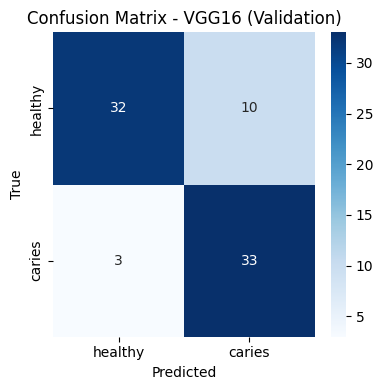

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_vgg_val = confusion_matrix(y_val, y_val_pred_vgg)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm_vgg_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "caries"],
    yticklabels=["healthy", "caries"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - VGG16 (Validation)")
plt.tight_layout()
plt.show()


VGG16 Test loss: 0.5014
VGG16 Test accuracy: 0.7895
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step

Detailed VGG16 Test Metrics:
Accuracy : 0.7895
Precision: 0.1111
Recall   : 1.0000
F1-score : 0.2000

Classification report (VGG16, test):
              precision    recall  f1-score   support

     healthy       1.00      0.78      0.88        37
      caries       0.11      1.00      0.20         1

    accuracy                           0.79        38
   macro avg       0.56      0.89      0.54        38
weighted avg       0.98      0.79      0.86        38



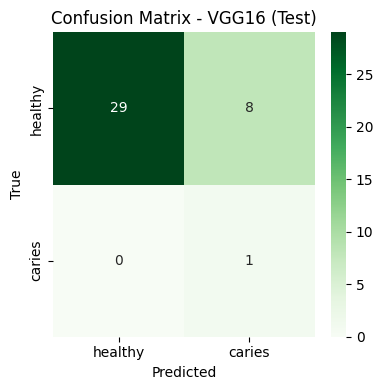

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_loss_vgg, test_acc_vgg = vgg_model.evaluate(X_test_rgb, y_test, verbose=0)
print(f"VGG16 Test loss: {test_loss_vgg:.4f}")
print(f"VGG16 Test accuracy: {test_acc_vgg:.4f}")

y_test_prob_vgg = vgg_model.predict(X_test_rgb)
y_test_pred_vgg = (y_test_prob_vgg >= 0.5).astype("int32").ravel()

acc  = accuracy_score(y_test, y_test_pred_vgg)
prec = precision_score(y_test, y_test_pred_vgg, zero_division=0)
rec  = recall_score(y_test, y_test_pred_vgg, zero_division=0)
f1   = f1_score(y_test, y_test_pred_vgg, zero_division=0)

print("\nDetailed VGG16 Test Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report (VGG16, test):")
print(classification_report(y_test, y_test_pred_vgg, target_names=["healthy", "caries"]))

cm_vgg_test = confusion_matrix(y_test, y_test_pred_vgg)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm_vgg_test,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["healthy", "caries"],
    yticklabels=["healthy", "caries"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - VGG16 (Test)")
plt.tight_layout()
plt.show()


In [57]:
import cv2
import glob
import numpy as np
import os

IMG_SIZE = 224

def load_split_with_clahe(images_dir):
    X_list = []
    y_list = []

    image_paths = glob.glob(os.path.join(images_dir, "*.*"))
    print(f"{images_dir} → {len(image_paths)} images")

    # CLAHE object (you can tune clipLimit & tileGridSize later)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # 1) contrast enhancement (CLAHE)
        img = clahe.apply(img)

        # 2) light denoising
        img = cv2.GaussianBlur(img, (3, 3), 0)

        # label from filename
        fname = os.path.basename(path).lower()
        if "unhealthy_teeth" in fname:
            label = 1
        elif "healthy_teeth" in fname:
            label = 0
        else:
            continue

        X_list.append(img)
        y_list.append(label)

    X = np.array(X_list, dtype=np.float32)[..., np.newaxis]
    y = np.array(y_list, dtype=np.int32)

    print(" shape:", X.shape, y.shape)
    unique, counts = np.unique(y, return_counts=True)
    print(" class counts:", dict(zip(unique, counts)))
    return X, y

# load all three splits with CLAHE
val_images_dir  = os.path.join(dataset_root, "valid", "images")
test_images_dir = os.path.join(dataset_root, "test", "images")
train_images_dir = os.path.join(dataset_root, "train", "images")

X_train_ce, y_train_ce = load_split_with_clahe(train_images_dir)
X_val_ce,   y_val_ce   = load_split_with_clahe(val_images_dir)
X_test_ce,  y_test_ce  = load_split_with_clahe(test_images_dir)

# normalize to [0, 1]
X_train_ce /= 255.0
X_val_ce   /= 255.0
X_test_ce  /= 255.0


/content/dental_dataset/Cavity Dataset/train/images → 287 images
 shape: (236, 224, 224, 1) (236,)
 class counts: {np.int32(0): np.int64(61), np.int32(1): np.int64(175)}
/content/dental_dataset/Cavity Dataset/valid/images → 93 images
 shape: (78, 224, 224, 1) (78,)
 class counts: {np.int32(0): np.int64(42), np.int32(1): np.int64(36)}
/content/dental_dataset/Cavity Dataset/test/images → 38 images
 shape: (38, 224, 224, 1) (38,)
 class counts: {np.int32(0): np.int64(37), np.int32(1): np.int64(1)}


In [59]:
import numpy as np

def to_rgb(x):
    # (N, H, W, 1) -> (N, H, W, 3)
    return np.repeat(x, 3, axis=-1)

X_train_ce_rgb = to_rgb(X_train_ce)
X_val_ce_rgb   = to_rgb(X_val_ce)
X_test_ce_rgb  = to_rgb(X_test_ce)

print("X_train_ce_rgb shape:", X_train_ce_rgb.shape)
print("X_val_ce_rgb shape  :", X_val_ce_rgb.shape)
print("X_test_ce_rgb shape :", X_test_ce_rgb.shape)


X_train_ce_rgb shape: (236, 224, 224, 3)
X_val_ce_rgb shape  : (78, 224, 224, 3)
X_test_ce_rgb shape : (38, 224, 224, 3)


In [60]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import tensorflow as tf

input_shape_rgb = (IMG_SIZE, IMG_SIZE, 3)

def create_vgg16_tl_clahe(input_shape):
    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False   # keep as feature extractor

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

vgg_clahe_model = create_vgg16_tl_clahe(input_shape_rgb)
vgg_clahe_model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [61]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

# class weights (same labels as before)
classes = np.unique(y_train_ce)
class_weights_ce = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_ce
)
vgg_clahe_class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_ce)}
print("Class weights (VGG16 + CLAHE):", vgg_clahe_class_weight)

# callbacks
vgg_clahe_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

vgg_clahe_ckpt = tf.keras.callbacks.ModelCheckpoint(
    "vgg16_tl_clahe_best.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# train
history_vgg_clahe = vgg_clahe_model.fit(
    X_train_ce_rgb, y_train_ce,
    validation_data=(X_val_ce_rgb, y_val_ce),
    epochs=25,
    batch_size=16,
    class_weight=vgg_clahe_class_weight,
    callbacks=[vgg_clahe_early, vgg_clahe_ckpt],
    verbose=1
)


Class weights (VGG16 + CLAHE): {0: 1.9344262295081966, 1: 0.6742857142857143}
Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5989 - loss: 0.6997
Epoch 1: val_loss improved from inf to 0.69333, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 133s 9s/step - accuracy: 0.5961 - loss: 0.7038 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5337 - loss: 0.7339
Epoch 2: val_loss improved from 0.69333 to 0.66660, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 141s 9s/step - accuracy: 0.5340 - loss: 0.7351 - val_accuracy: 0.7051 - val_loss: 0.6666
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5128 - loss: 0.6490
Epoch 3: val_loss improved from 0.66660 to 0.64687, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 131s 9s/step - accuracy: 0.5144 - loss: 0.6508 - val_accuracy: 0.7692 - val_loss: 0.6469
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5728 - loss: 0.6830
Epoch 4: val_loss improved from 0.64687 to 0.62873, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 130s 9s/step - accuracy: 0.5727 - loss: 0.6804 - val_accuracy: 0.7692 - val_loss: 0.6287
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6391 - loss: 0.6317
Epoch 5: val_loss improved from 0.62873 to 0.61997, saving model to vgg16_tl_clahe_best.h5


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 153s 9s/step - accuracy: 0.8165 - loss: 0.4449 - val_accuracy: 0.8205 - val_loss: 0.4693
Epoch 22/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7837 - loss: 0.4481
Epoch 22: val_loss improved from 0.46933 to 0.46608, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 143s 9s/step - accuracy: 0.7842 - loss: 0.4481 - val_accuracy: 0.8077 - val_loss: 0.4661
Epoch 23/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8467 - loss: 0.4358
Epoch 23: val_loss improved from 0.46608 to 0.46598, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 131s 9s/step - accuracy: 0.8462 - loss: 0.4373 - val_accuracy: 0.8205 - val_loss: 0.4660
Epoch 24/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8082 - loss: 0.4942
Epoch 24: val_loss improved from 0.46598 to 0.45536, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 131s 9s/step - accuracy: 0.8077 - loss: 0.4940 - val_accuracy: 0.8205 - val_loss: 0.4554
Epoch 25/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8439 - loss: 0.4264
Epoch 25: val_loss improved from 0.45536 to 0.44920, saving model to vgg16_tl_clahe_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 121s 8s/step - accuracy: 0.8418 - loss: 0.4276 - val_accuracy: 0.8205 - val_loss: 0.4492


In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1) predict on validation (CLAHE version)
y_val_prob_vgg_ce = vgg_clahe_model.predict(X_val_ce_rgb)
y_val_pred_vgg_ce = (y_val_prob_vgg_ce >= 0.5).astype("int32").ravel()

print("Shapes:", y_val_ce.shape, y_val_pred_vgg_ce.shape)

# 2) metrics
acc_ce  = accuracy_score(y_val_ce, y_val_pred_vgg_ce)
prec_ce = precision_score(y_val_ce, y_val_pred_vgg_ce, zero_division=0)
rec_ce  = recall_score(y_val_ce, y_val_pred_vgg_ce, zero_division=0)
f1_ce   = f1_score(y_val_ce, y_val_pred_vgg_ce, zero_division=0)

print(f"VGG16 + CLAHE Val accuracy : {acc_ce:.4f}")
print(f"VGG16 + CLAHE Val precision: {prec_ce:.4f}")
print(f"VGG16 + CLAHE Val recall   : {rec_ce:.4f}")
print(f"VGG16 + CLAHE Val F1-score : {f1_ce:.4f}")

print("\nClassification report (VGG16 + CLAHE, val):")
print(classification_report(y_val_ce, y_val_pred_vgg_ce,
                            target_names=["healthy", "caries"]))


NameError: name 'vgg_clahe_model' is not defined

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_vgg_ce_val = confusion_matrix(y_val_ce, y_val_pred_vgg_ce)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm_vgg_ce_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "caries"],
    yticklabels=["healthy", "caries"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - VGG16 + CLAHE (Validation)")
plt.tight_layout()
plt.show()


NameError: name 'y_val_ce' is not defined

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === Recompute metrics for each model on VALIDATION data ===

# 1) Custom CNN (grayscale, no CLAHE)
y_val_prob_custom = custom_model.predict(X_val)
y_val_pred_custom = (y_val_prob_custom >= 0.5).astype("int32").ravel()

metrics_custom = {
    "Model": "Custom CNN",
    "Accuracy":  accuracy_score(y_val, y_val_pred_custom),
    "Precision": precision_score(y_val, y_val_pred_custom, zero_division=0),
    "Recall":    recall_score(y_val, y_val_pred_custom, zero_division=0),
    "F1-score":  f1_score(y_val, y_val_pred_custom, zero_division=0),
}

# 2) VGG16 (raw RGB, no CLAHE)
y_val_pred_vgg = (y_val_prob_vgg >= 0.5).astype("int32").ravel()

metrics_vgg = {
    "Model": "VGG16 (raw)",
    "Accuracy":  accuracy_score(y_val, y_val_pred_vgg),
    "Precision": precision_score(y_val, y_val_pred_vgg, zero_division=0),
    "Recall":    recall_score(y_val, y_val_pred_vgg, zero_division=0),
    "F1-score":  f1_score(y_val, y_val_pred_vgg, zero_division=0),
}

# 3) VGG16 + CLAHE
y_val_pred_vgg_ce = (y_val_prob_vgg_ce >= 0.5).astype("int32").ravel()

metrics_vgg_ce = {
    "Model": "VGG16 + CLAHE",
    "Accuracy":  accuracy_score(y_val_ce, y_val_pred_vgg_ce),
    "Precision": precision_score(y_val_ce, y_val_pred_vgg_ce, zero_division=0),
    "Recall":    recall_score(y_val_ce, y_val_pred_vgg_ce, zero_division=0),
    "F1-score":  f1_score(y_val_ce, y_val_pred_vgg_ce, zero_division=0),
}

# === Put everything in one DataFrame ===
results_df = pd.DataFrame([metrics_custom, metrics_vgg, metrics_vgg_ce])
results_df


NameError: name 'custom_model' is not defined

In [34]:
import os
from google.colab import files

print(os.listdir())   # check that vgg16_tl_clahe_best.h5 is here

files.download("vgg16_tl_clahe_best.h5")


['.config', 'vgg16_tl_best.h5', 'archive.zip', 'custom_cnn_best.h5', 'dental_dataset', 'vgg16_tl_clahe_best.h5', 'sample_data']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import os
import numpy as np

def get_severity_from_txt(txt_path, early_threshold=0.02):
    """
    Reads a YOLO-style .txt file and returns:
      1 = early caries
      2 = advanced caries
    based on the TOTAL area of all bounding boxes in the file.

    If the file does not exist or has no boxes, it returns 0 for now
    (we will treat that case carefully when we use it).
    """
    if not os.path.exists(txt_path):
        return 0  # no file

    with open(txt_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    if len(lines) == 0:
        return 0  # no boxes

    areas = []
    for line in lines:
        parts = line.split()
        if len(parts) != 5:
            continue
        # YOLO format: class x_center y_center width height (all relative 0–1)
        _, _, _, w, h = parts
        w = float(w)
        h = float(h)
        areas.append(w * h)

    total_area = float(np.sum(areas))

    # Heuristic: small total area -> early, large -> advanced
    if total_area < early_threshold:
        return 1  # early caries
    else:
        return 2  # advanced caries


In [11]:
import cv2
import glob

IMG_SIZE = 224

def load_split_severity(images_dir, labels_dir, early_threshold=0.02):
    """
    Load one split (e.g. train) and create 3 labels:
      0 = healthy
      1 = early caries   (small total cavity area)
      2 = advanced caries (large total cavity area)
    """
    X_list = []
    y_list = []

    image_paths = glob.glob(os.path.join(images_dir, "*.*"))
    print(f"{images_dir} → {len(image_paths)} images")

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = clahe.apply(img)
        img = cv2.GaussianBlur(img, (3, 3), 0)
        img = img.astype("float32") / 255.0

        fname = os.path.basename(img_path).lower()
        base_name = os.path.splitext(fname)[0]
        txt_path = os.path.join(labels_dir, base_name + ".txt")

        # IMPORTANT: check "unhealthy" FIRST
        if "unhealthy_teeth" in fname:
            severity = get_severity_from_txt(txt_path, early_threshold)
            if severity == 0:
                label = 1  # fallback to early
            else:
                label = severity       # 1 = early, 2 = advanced
        elif "healthy_teeth" in fname:
            label = 0
        else:
            continue

        X_list.append(img)
        y_list.append(label)

    X = np.array(X_list, dtype=np.float32)[..., np.newaxis]
    y = np.array(y_list, dtype=np.int32)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    unique, counts = np.unique(y, return_counts=True)
    print("Class counts:", dict(zip(unique, counts)))
    return X, y


In [12]:
train_images_dir = os.path.join(dataset_root, "train", "images")
train_labels_dir = os.path.join(dataset_root, "train", "labelTxt")

X_train3, y_train3 = load_split_severity(train_images_dir, train_labels_dir)


/content/dental_dataset/Cavity Dataset/train/images → 287 images
X shape: (236, 224, 224, 1)
y shape: (236,)
Class counts: {np.int32(0): np.int64(61), np.int32(1): np.int64(175)}


In [13]:
# Try a smaller threshold to separate early vs advanced
X_train3, y_train3 = load_split_severity(
    train_images_dir,
    train_labels_dir,
    early_threshold=0.005   # was 0.02 before
)


/content/dental_dataset/Cavity Dataset/train/images → 287 images
X shape: (236, 224, 224, 1)
y shape: (236,)
Class counts: {np.int32(0): np.int64(61), np.int32(1): np.int64(175)}


In [14]:
import os
import numpy as np

def get_severity_from_txt(txt_path, dummy_threshold=None):
    """
    Reads a YOLO-style .txt file and returns:
      1 = early caries    (1 cavity box)
      2 = advanced caries (2 or more cavity boxes)

    If the file does not exist or has no boxes, returns 0.
    """
    if not os.path.exists(txt_path):
        return 0

    with open(txt_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    n_boxes = len(lines)
    if n_boxes == 0:
        return 0
    elif n_boxes == 1:
        return 1   # early
    else:
        return 2   # advanced


In [15]:
X_train3, y_train3 = load_split_severity(
    train_images_dir,
    train_labels_dir,
    early_threshold=0.0   # value not used anymore, but keep the argument
)


/content/dental_dataset/Cavity Dataset/train/images → 287 images
X shape: (236, 224, 224, 1)
y shape: (236,)
Class counts: {np.int32(0): np.int64(61), np.int32(1): np.int64(3), np.int32(2): np.int64(172)}


In [16]:
# VALIDATION split (3-class labels)
val_images_dir   = os.path.join(dataset_root, "valid", "images")
val_labels_dir   = os.path.join(dataset_root, "valid", "labelTxt")

X_val3, y_val3 = load_split_severity(
    val_images_dir,
    val_labels_dir,
    early_threshold=0.0  # not used in current severity rule
)


/content/dental_dataset/Cavity Dataset/valid/images → 93 images
X shape: (78, 224, 224, 1)
y shape: (78,)
Class counts: {np.int32(0): np.int64(42), np.int32(1): np.int64(1), np.int32(2): np.int64(35)}


In [17]:
# TEST split (3-class labels)
test_images_dir  = os.path.join(dataset_root, "test", "images")
test_labels_dir  = os.path.join(dataset_root, "test", "labelTxt")

X_test3, y_test3 = load_split_severity(
    test_images_dir,
    test_labels_dir,
    early_threshold=0.0  # not used in current severity rule
)


/content/dental_dataset/Cavity Dataset/test/images → 38 images
X shape: (38, 224, 224, 1)
y shape: (38,)
Class counts: {np.int32(0): np.int64(37), np.int32(2): np.int64(1)}


In [9]:
import numpy as np

def to_rgb(x):
    """
    Input:  (N, 224, 224, 1)
    Output: (N, 224, 224, 3) by repeating the channel.
    """
    return np.repeat(x, 3, axis=-1)

X_train3_rgb = to_rgb(X_train3)
X_val3_rgb   = to_rgb(X_val3)
X_test3_rgb  = to_rgb(X_test3)

print("X_train3_rgb:", X_train3_rgb.shape)
print("X_val3_rgb  :", X_val3_rgb.shape)
print("X_test3_rgb :", X_test3_rgb.shape)
print("y_train3    :", y_train3.shape)
print("y_val3      :", y_val3.shape)
print("y_test3     :", y_test3.shape)


NameError: name 'X_train3' is not defined

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import tensorflow as tf

IMG_SIZE = 224
input_shape_rgb = (IMG_SIZE, IMG_SIZE, 3)
NUM_CLASSES = 3  # healthy, early, advanced

def create_vgg16_3class(input_shape):
    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False  # feature extractor

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

vgg_3class = create_vgg16_3class(input_shape_rgb)
vgg_3class.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

# Compute class weights for 3 classes: 0,1,2
classes = np.unique(y_train3)
class_weights_3 = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train3
)
class_weights_3 = {int(c): float(w) for c, w in zip(classes, class_weights_3)}
print("Class weights:", class_weights_3)

# Callbacks
early_stop_3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

ckpt_3 = tf.keras.callbacks.ModelCheckpoint(
    "vgg16_tl_clahe_3class.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train
history_3 = vgg_3class.fit(
    X_train3_rgb, y_train3,
    validation_data=(X_val3_rgb, y_val3),
    epochs=25,
    batch_size=16,
    class_weight=class_weights_3,
    callbacks=[early_stop_3, ckpt_3],
    verbose=1
)


NameError: name 'y_train3' is not defined

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Predictions on validation ----
y_val3_prob = vgg_3class.predict(X_val3_rgb)
y_val3_pred = np.argmax(y_val3_prob, axis=1)

print("Shapes:", y_val3_pred.shape, y_val3.shape)

# ---- Classification report ----
target_names = ["Healthy (0)", "Early caries (1)", "Advanced caries (2)"]
print("Validation classification report (3-class):")
print(classification_report(y_val3, y_val3_pred, target_names=target_names, digits=3))

# ---- Confusion matrix ----
cm = confusion_matrix(y_val3, y_val3_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – VGG16 + CLAHE (3 classes, Val)")
plt.show()


NameError: name 'X_val3_rgb' is not defined

In [14]:
import os, glob
import numpy as np

train_images_dir = os.path.join(dataset_root, "train", "images")
train_labels_dir = os.path.join(dataset_root, "train", "labelTxt")

def compute_unhealthy_box_counts(images_dir, labels_dir):
    counts = []
    for img_path in glob.glob(os.path.join(images_dir, "*.*")):
        fname = os.path.basename(img_path).lower()
        if "unhealthy_teeth" not in fname:
            continue

        base_name = os.path.splitext(fname)[0]
        txt_path = os.path.join(labels_dir, base_name + ".txt")
        if not os.path.exists(txt_path):
            continue

        with open(txt_path, "r") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]

        n_boxes = len(lines)
        if n_boxes > 0:
            counts.append(n_boxes)

    counts = np.array(counts)
    print("Number of unhealthy images with at least 1 box:", len(counts))
    print("Min boxes:", counts.min())
    print("Max boxes:", counts.max())
    print("Unique counts and frequencies:",
          dict(zip(*np.unique(counts, return_counts=True))))
    print("Median box count:", np.median(counts))
    return counts

box_counts = compute_unhealthy_box_counts(train_images_dir, train_labels_dir)
BOX_THRESHOLD = int(np.median(box_counts))
print("Chosen BOX_THRESHOLD:", BOX_THRESHOLD)


NameError: name 'dataset_root' is not defined

In [15]:
import os

def get_severity_from_txt(txt_path, box_threshold=None):
    """
    Uses the NUMBER of bounding boxes to decide severity:
      1 = early caries    (n_boxes <= box_threshold)
      2 = advanced caries (n_boxes >  box_threshold)

    If file is missing or has 0 boxes -> return 0 (we handle later).
    """
    if not os.path.exists(txt_path):
        return 0

    with open(txt_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    n_boxes = len(lines)
    if n_boxes == 0:
        return 0

    if box_threshold is None:
        # default to global BOX_THRESHOLD computed earlier
        box_threshold = BOX_THRESHOLD

    if n_boxes <= box_threshold:
        return 1   # early
    else:
        return 2   # advanced


In [17]:
import cv2
import glob
import numpy as np

IMG_SIZE = 224  # same as before

def load_split_severity(images_dir, labels_dir):
    """
    Load one split (e.g. train) and create 3 labels:
      0 = healthy
      1 = early caries    (n_boxes <= BOX_THRESHOLD)
      2 = advanced caries (n_boxes >  BOX_THRESHOLD)
    """
    X_list = []
    y_list = []

    image_paths = glob.glob(os.path.join(images_dir, "*.*"))
    print(f"{images_dir} → {len(image_paths)} images")

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = clahe.apply(img)
        img = cv2.GaussianBlur(img, (3, 3), 0)
        img = img.astype("float32") / 255.0

        fname = os.path.basename(img_path).lower()
        base_name = os.path.splitext(fname)[0]
        txt_path = os.path.join(labels_dir, base_name + ".txt")

        if "unhealthy_teeth" in fname:
            # use NEW severity function: number of boxes vs BOX_THRESHOLD
            severity = get_severity_from_txt(txt_path)

            if severity == 0:
                # fallback: if somehow no boxes, at least call it early
                label = 1
            else:
                label = severity      # 1 = early, 2 = advanced
        elif "healthy_teeth" in fname:
            label = 0
        else:
            continue

        X_list.append(img)
        y_list.append(label)

    X = np.array(X_list, dtype=np.float32)[..., np.newaxis]
    y = np.array(y_list, dtype=np.int32)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    unique, counts = np.unique(y, return_counts=True)
    print("Class counts:", dict(zip(unique, counts)))
    return X, y


In [23]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import tensorflow as tf

IMG_SIZE = 224
input_shape_rgb = (IMG_SIZE, IMG_SIZE, 3)
NUM_CLASSES = 3  # 0=healthy, 1=early, 2=advanced

def create_vgg16_3class(input_shape):
    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False  # use as feature extractor

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

vgg_3class = create_vgg16_3class(input_shape_rgb)
vgg_3class.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

# 1. Plot training curves
def plot_history(history, title_prefix, filename=None):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(10,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="train acc")
    plt.plot(epochs, val_acc, label="val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} – Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="train loss")
    plt.plot(epochs, val_loss, label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} – Loss")
    plt.legend()

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# 2. Evaluate + confusion matrix
def eval_and_confusion(model, X, y, class_names, split_name, filename=None):
    """
    model: Keras model
    X, y : data and labels
    class_names: list of strings, one per class
    split_name: "Validation", "Test", etc.
    filename: if not None, save confusion matrix figure to this path
    """
    num_classes = len(class_names)

    # Predict
    probs = model.predict(X)
    if num_classes == 2 and probs.shape[-1] == 1:
        # binary sigmoid
        y_pred = (probs.ravel() >= 0.5).astype(int)
    else:
        # softmax
        y_pred = np.argmax(probs, axis=1)

    print("Shapes:", y_pred.shape, y.shape)
    print(f"\n{split_name} classification report:")
    print(classification_report(y, y_pred, target_names=class_names, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix – {split_name}")
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    return probs, y_pred, cm


In [12]:
!pip install opencv-python-headless -q

import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Root of your dataset (adjust if different)
dataset_root = "/content/dental_dataset/Cavity Dataset"

print("Dataset root:", dataset_root)


Dataset root: /content/dental_dataset/Cavity Dataset


In [13]:
IMG_SIZE = 224

# Image preprocessing (grayscale + CLAHE + 3-channel)
def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # normalize to [0,1]
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)         # (H,W,1)
    img = np.repeat(img, 3, axis=-1)           # (H,W,3)
    return img


def count_boxes(label_path):
    """Count number of YOLO boxes for this image."""
    if not os.path.exists(label_path):
        return 0
    with open(label_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    return len(lines)


def label_from_filename_and_boxes(img_name, label_dir):
    # healthy if filename contains 'healthy_teeth'
    if "healthy_teeth" in img_name:
        return 0  # healthy

    # otherwise carious → use number of boxes
    base = os.path.splitext(img_name)[0]
    label_path = os.path.join(label_dir, base + ".txt")
    n = count_boxes(label_path)

    if 1 <= n <= 10:
        return 1  # early
    elif n > 10:
        return 2  # advanced
    else:
        # fallback: if unhealthy but 0 boxes, treat as early
        return 1


def load_split(split_name):
    """
    split_name: 'train', 'valid', or 'test'
    returns: X_rgb (N,224,224,3), y (N,)
    """
    img_dir = os.path.join(dataset_root, split_name, "images")
    label_dir = os.path.join(dataset_root, split_name, "labelTxt")

    img_files = sorted([f for f in os.listdir(img_dir)
                        if f.lower().endswith((".jpg", ".jpeg", ".png"))])

    X_list, y_list = [], []
    for fname in img_files:
        path = os.path.join(img_dir, fname)
        X_list.append(preprocess_image(path))
        y_list.append(label_from_filename_and_boxes(fname, label_dir))

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.int32)

    print(f"{split_name} → X: {X.shape}, y: {y.shape}, class counts:",
          {c: int((y == c).sum()) for c in np.unique(y)})
    return X, y


X_train3_rgb, y_train3 = load_split("train")
X_val3_rgb,   y_val3   = load_split("valid")
X_test3_rgb,  y_test3  = load_split("test")


train → X: (287, 224, 224, 3), y: (287,), class counts: {np.int32(0): 236, np.int32(1): 15, np.int32(2): 36}
valid → X: (93, 224, 224, 3), y: (93,), class counts: {np.int32(0): 78, np.int32(1): 3, np.int32(2): 12}
test → X: (38, 224, 224, 3), y: (38,), class counts: {np.int32(0): 38}


In [24]:
def build_vgg16_clahe_3class():
    base = VGG16(include_top=False,
                 weights="imagenet",
                 input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(3, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="vgg16_clahe_3class")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


model_vgg16_clahe_3class = build_vgg16_clahe_3class()
model_vgg16_clahe_3class.summary()

model_vgg16_clahe_3class.load_weights("vgg16_tl_clahe_3class.h5")

print("Loaded weights from vgg16_tl_clahe_3class.h5")


Model: "vgg16_clahe_3class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Loaded weights from vgg16_tl_clahe_3class.h5


In [23]:
from google.colab import files
uploaded = files.upload()
print(uploaded.keys())


Saving vgg16_tl_clahe_3class.h5 to vgg16_tl_clahe_3class.h5
dict_keys(['vgg16_tl_clahe_3class.h5'])


3/3 ━━━━━━━━━━━━━━━━━━━━ 54s 15s/step
y_val_bin shape: (93,)
y_val_proba shape: (93,)
AUC = 0.744


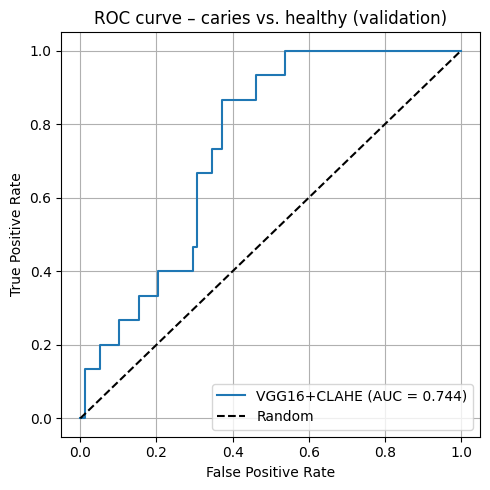

In [25]:
y_val_bin = (y_val3 != 0).astype(int)

y_val_proba_all = model_vgg16_clahe_3class.predict(X_val3_rgb)
y_val_proba = y_val_proba_all[:, 1] + y_val_proba_all[:, 2]

print("y_val_bin shape:", y_val_bin.shape)
print("y_val_proba shape:", y_val_proba.shape)

# 3) ROC + AUC
fpr, tpr, _ = roc_curve(y_val_bin, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC = {roc_auc:.3f}")

# 4) Plot and save
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"VGG16+CLAHE (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – caries vs. healthy (validation)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_roc_vgg16_clahe_3class.png", dpi=300)
plt.show()


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [29]:
X_train2_rgb = X_train3_rgb
y_train2 = y_train3
X_val2_rgb = X_val3_rgb
y_val2 = y_val3

print("X_train2_rgb shape:", X_train2_rgb.shape)
print("y_train2 shape:", y_train2.shape)
print("X_val2_rgb shape:", X_val2_rgb.shape)
print("y_val2 shape:", y_val2.shape)

X_train2_rgb shape: (287, 224, 224, 3)
y_train2 shape: (287,)
X_val2_rgb shape: (93, 224, 224, 3)
y_val2 shape: (93,)


In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# --- 1) Data augmentation generator for training ---
train_datagen = ImageDataGenerator(
    rotation_range=10,        # small random rotations
    width_shift_range=0.05,   # horizontal shifts
    height_shift_range=0.05,  # vertical shifts
    zoom_range=0.10,          # random zoom
    horizontal_flip=True,     # flip teeth left/right
    fill_mode="nearest"       # fill pixels after transforms
)

train_datagen.fit(X_train2_rgb)

val_datagen = ImageDataGenerator()

num_classes = 3
y_train2_cat = to_categorical(y_train2, num_classes=num_classes)
y_val2_cat   = to_categorical(y_val2,   num_classes=num_classes)

inputs = tf.keras.Input(shape=(224, 224, 3))
base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)
base_model.trainable = False  # freeze convolutional layers

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model_vgg16_tl_clahe_3class = tf.keras.Model(inputs=inputs, outputs=outputs)

model_vgg16_tl_clahe_3class.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_vgg16_tl_clahe_3class.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [38]:
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Keep the original integer labels for metrics
y_val2_int = y_val2

# One-hot version for Keras (3 classes: 0,1,2)
y_val2_cat = to_categorical(y_val2_int, num_classes=3)


In [40]:
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


In [41]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

datagen.fit(X_train2_rgb)  # only on training data


In [42]:
base_model = VGG16(include_top=False,
                   weights="imagenet",
                   input_shape=(224, 224, 3))
base_model.trainable = False  # freeze conv layers

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(3, activation="softmax")(x)

model_vgg16_clahe_3class_aug = Model(inputs, outputs,
                                     name="vgg16_clahe_3class_aug")

model_vgg16_clahe_3class_aug.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",  # <-- integer labels
    metrics=["accuracy"]
)

model_vgg16_clahe_3class_aug.summary()


Model: "vgg16_clahe_3class_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [43]:
classes = np.array([0, 1, 2])
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train2
)
class_weights = dict(zip(classes, class_weights_values))
print("Class weights:", class_weights)


Class weights: {np.int64(0): np.float64(0.4053672316384181), np.int64(1): np.float64(6.377777777777778), np.int64(2): np.float64(2.6574074074074074)}


In [44]:
batch_size = 16

history_vgg16_clahe_3class_aug = model_vgg16_clahe_3class_aug.fit(
    datagen.flow(X_train2_rgb, y_train2, batch_size=batch_size, shuffle=True),
    epochs=12,
    validation_data=(X_val2_rgb, y_val2),
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss",
                      patience=5,
                      restore_best_weights=True)
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 198s 11s/step - accuracy: 0.1478 - loss: 1.3040 - val_accuracy: 0.0753 - val_loss: 1.3115
Epoch 2/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 228s 13s/step - accuracy: 0.3314 - loss: 1.2228 - val_accuracy: 0.4946 - val_loss: 1.0700
Epoch 3/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 226s 13s/step - accuracy: 0.3732 - loss: 1.2629 - val_accuracy: 0.7204 - val_loss: 1.0059
Epoch 4/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 227s 13s/step - accuracy: 0.4403 - loss: 1.1142 - val_accuracy: 0.7204 - val_loss: 0.9927
Epoch 5/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 190s 11s/step - accuracy: 0.4039 - loss: 0.9595 - val_accuracy: 0.7849 - val_loss: 0.9712
Epoch 6/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 227s 13s/step - accuracy: 0.4296 - loss: 1.0622 - val_accuracy: 0.6452 - val_loss: 1.0156
Epoch 7/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 226s 13s/step - accuracy: 0.4033 - loss: 0.9476 - val_accuracy: 0.6882 - val_loss: 0.9816
Epoch 8/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 227s 13s/step - accuracy: 0.4966 - loss: 1.0033 - val_accuracy: 0.

Augmented model – Val accuracy: 0.7527, Val loss: 0.9054
3/3 ━━━━━━━━━━━━━━━━━━━━ 46s 15s/step

Classification report (augmented model):
                 precision    recall  f1-score   support

        Healthy       0.94      0.76      0.84        78
   Early caries       0.12      0.33      0.18         3
Advanced caries       0.45      0.83      0.59        12

       accuracy                           0.75        93
      macro avg       0.51      0.64      0.54        93
   weighted avg       0.85      0.75      0.78        93



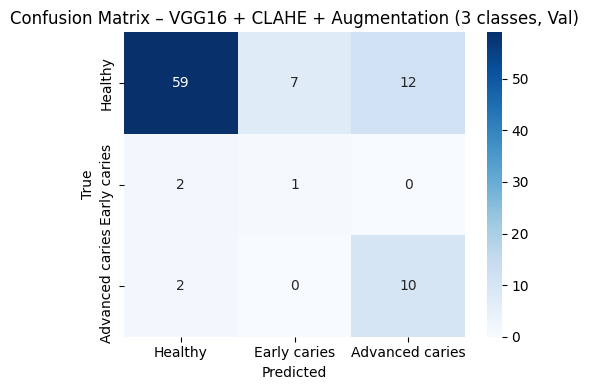

In [45]:
# 1) Accuracy on validation set
val_loss, val_acc = model_vgg16_clahe_3class_aug.evaluate(
    X_val2_rgb, y_val2, verbose=0
)
print(f"Augmented model – Val accuracy: {val_acc:.4f}, Val loss: {val_loss:.4f}")

# 2) Predictions
y_val_pred_proba = model_vgg16_clahe_3class_aug.predict(X_val2_rgb)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

target_names = ["Healthy", "Early caries", "Advanced caries"]

print("\nClassification report (augmented model):")
print(classification_report(y_val2, y_val_pred, target_names=target_names))

cm = confusion_matrix(y_val2, y_val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – VGG16 + CLAHE + Augmentation (3 classes, Val)")
plt.tight_layout()
plt.show()


In [35]:
# Use the transfer-learning + CLAHE 3-class model as the "augmented" one
model_vgg16_clahe_3class_aug = model_vgg16_tl_clahe_3class


In [30]:
import numpy as np

print("y_train2 classes and counts:", np.unique(y_train2, return_counts=True))
print("y_val2 classes and counts:", np.unique(y_val2, return_counts=True))


y_train2 classes and counts: (array([0, 1, 2], dtype=int32), array([236,  15,  36]))
y_val2 classes and counts: (array([0, 1, 2], dtype=int32), array([78,  3, 12]))
